In [13]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [14]:
sales = pd.read_csv("sales.csv", sep = ",")
sales.head(5)

,Store ID,Store_Area,Items_Available,Daily_Customer_Count,Store_Sales
0,1,1659,1961,530,66490
1,2,1461,1752,210,39820
2,3,1340,1609,720,54010
3,4,1451,1748,620,53730
4,5,1770,2111,450,46620


In [15]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 896 entries, 0 to 895
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Store ID              896 non-null    int64
 1   Store_Area            896 non-null    int64
 2   Items_Available       896 non-null    int64
 3   Daily_Customer_Count  896 non-null    int64
 4   Store_Sales           896 non-null    int64
dtypes: int64(5)
memory usage: 35.1 KB


In [16]:
sales.isnull().sum()

Store ID                0
Store_Area              0
Items_Available         0
Daily_Customer_Count    0
Store_Sales             0
dtype: int64

In [17]:
sales.duplicated().sum()

np.int64(0)

In [18]:
sales.describe()

,Store ID,Store_Area,Items_Available,Daily_Customer_Count,Store_Sales
count,896.000000,896.000000,896.000000,896.000000,896.000000
mean,448.500000,1485.409598,1782.035714,786.350446,59351.305804
std,258.797218,250.237011,299.872053,265.389281,17190.741895
min,1.000000,775.000000,932.000000,10.000000,14920.000000
25%,224.750000,1316.750000,1575.500000,600.000000,46530.000000
50%,448.500000,1477.000000,1773.500000,780.000000,58605.000000
75%,672.250000,1653.500000,1982.750000,970.000000,71872.500000
max,896.000000,2229.000000,2667.000000,1560.000000,116320.000000


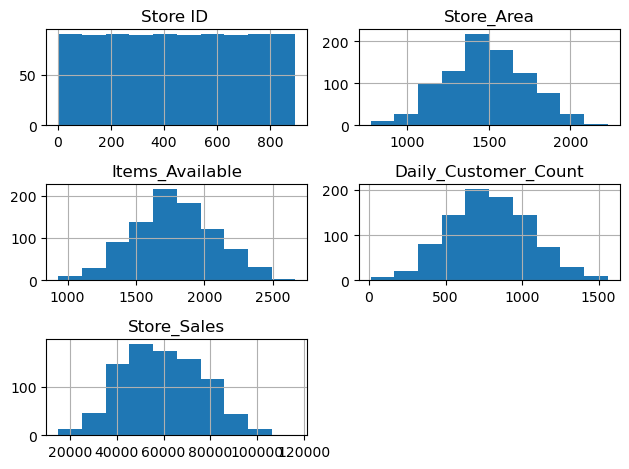

In [19]:
sales.hist()
plt.tight_layout()
plt.show()

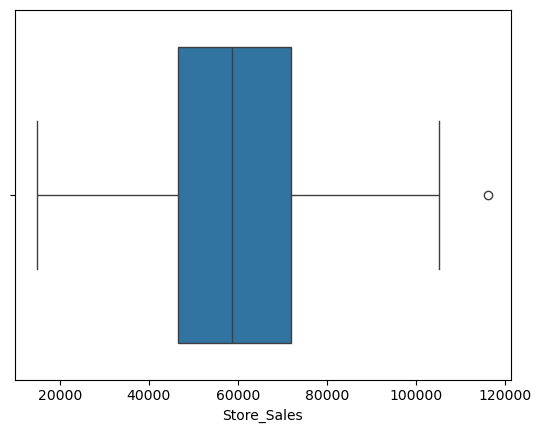

In [20]:
sns.boxplot(x = sales['Store_Sales'])
plt.show()

In [21]:
# Total sales 

sales["Store_Sales"].sum()

np.int64(53178770)

In [22]:
# Average sales 

sales["Store_Sales"].mean()

np.float64(59351.30580357143)

In [23]:
# Highest sales store

sales["Store_Sales"].max()


116320

In [24]:
# Average customer count

sales["Daily_Customer_Count"].mean()


np.float64(786.3504464285714)

In [25]:
# correlation analysis


sales.corr(numeric_only = True)

,Store ID,Store_Area,Items_Available,Daily_Customer_Count,Store_Sales
Store ID,1.000000,-0.058705,-0.055707,-0.010029,0.071486
Store_Area,-0.058705,1.000000,0.998891,-0.041423,0.097474
Items_Available,-0.055707,0.998891,1.000000,-0.040978,0.098849
Daily_Customer_Count,-0.010029,-0.041423,-0.040978,1.000000,0.008629
Store_Sales,0.071486,0.097474,0.098849,0.008629,1.000000


In [26]:
sales.corr(numeric_only=True)['Store_Sales']

Store ID                0.071486
Store_Area              0.097474
Items_Available         0.098849
Daily_Customer_Count    0.008629
Store_Sales             1.000000
Name: Store_Sales, dtype: float64

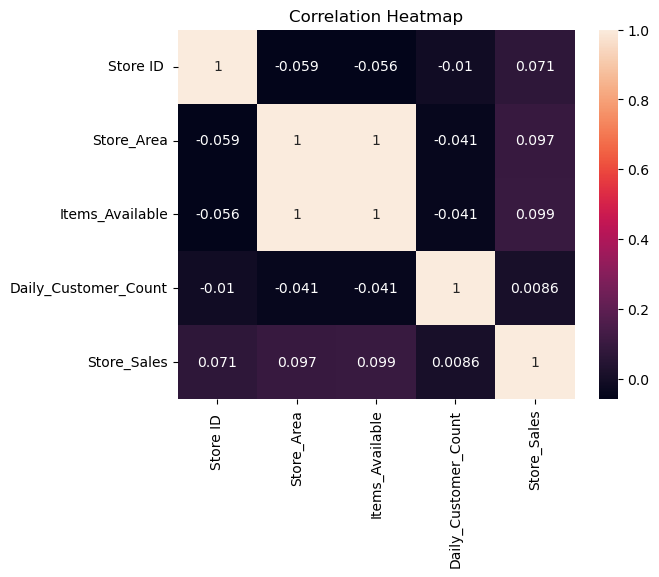

In [27]:
# making heat map 

sns.heatmap(
    sales.corr(numeric_only= True),
    annot = True
)

plt.title("Correlation Heatmap")
plt.show()

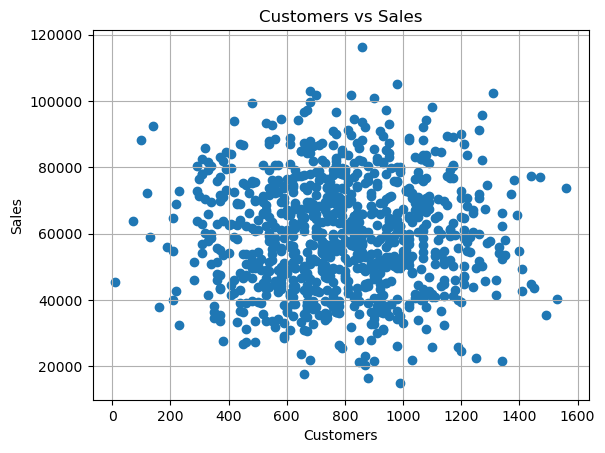

In [28]:
# Sactter plot 


plt.scatter(sales['Daily_Customer_Count'],sales['Store_Sales'])
plt.xlabel("Customers")

plt.ylabel("Sales")
plt.grid()
plt.title("Customers vs Sales")
plt.show()

In [29]:
# outliers + Distribution analysis

# unusal stores 
# abnormal sales 
# data spread 
# bussiness anomalies



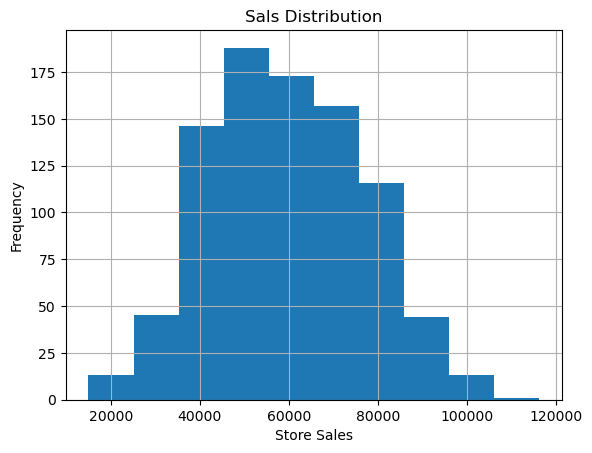

In [30]:
# <!-- # step1 -->

# <!-- store sales distriution  -->

import matplotlib.pyplot as plt

sales['Store_Sales'].hist()
plt.xlabel("Store Sales")
plt.ylabel("Frequency")
plt.title("Sals Distribution")
plt.show()


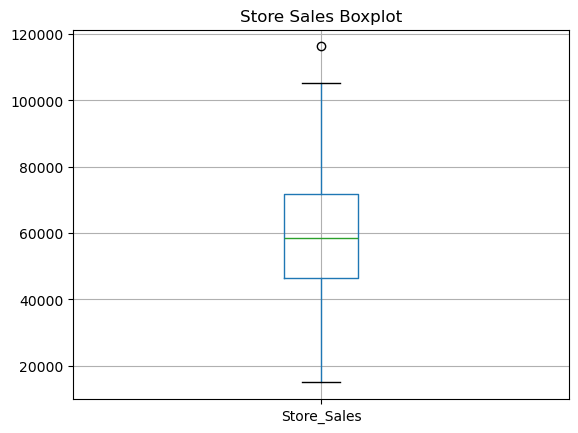

In [31]:
# box plot

sales.boxplot(column='Store_Sales')

plt.title("Store Sales Boxplot")
plt.show()

In [32]:
# find outliers store 

sales[sales['Store_Sales']>100000]


,Store ID,Store_Area,Items_Available,Daily_Customer_Count,Store_Sales
408,409,1303,1587,1310,102310
432,433,1365,1638,680,102920
557,558,1137,1374,700,101780
649,650,1989,2414,860,116320
758,759,1486,1758,820,101820
866,867,1565,1854,900,100900
868,869,1775,2104,980,105150


In [33]:
sales[sales['Store_Sales']<20000]


,Store ID,Store_Area,Items_Available,Daily_Customer_Count,Store_Sales
31,32,1250,1508,990,14920
775,776,1537,1877,660,17670
852,853,1477,1790,880,16370


In [34]:
#  compare top stores 

sales.sort_values(
    by= "Store_Sales",
    ascending = False
).head(10)

,Store ID,Store_Area,Items_Available,Daily_Customer_Count,Store_Sales
649,650,1989,2414,860,116320
868,869,1775,2104,980,105150
432,433,1365,1638,680,102920
408,409,1303,1587,1310,102310
758,759,1486,1758,820,101820
557,558,1137,1374,700,101780
866,867,1565,1854,900,100900
166,167,1465,1763,680,99570
692,693,1548,1858,480,99480
871,872,1800,2158,1100,98260


In [35]:
#  In ML 
# Store_Area
# Items_Available
# Daily_customer_count
# topredict:
# Store_Sales

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = sales[['Store_Area',
           'Items_Available',
           'Daily_Customer_Count']]

y = sales['Store_Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(predictions[:5])

[58025.07762612 61135.49379302 55438.9785545  61641.5658236
 57967.90940392]


In [37]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [38]:
# Check model accuracy 

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2_score = r2_score(y_test, predictions)

print("-"*50)
print("MAE(Mean_Absolute_Error):- ",mae)
print("-"*50)
print("MSE(Mean_Squared_Error):- ",mse)
print("-"*50)
print("R2_Score (Accuracy):- ",r2_score)
print("-"*50)



--------------------------------------------------
MAE(Mean_Absolute_Error):-  13270.805062164232
--------------------------------------------------
MSE(Mean_Squared_Error):-  270398518.29145896
--------------------------------------------------
R2_Score (Accuracy):-  0.006062836062981969
--------------------------------------------------


In [39]:
comparison = pd.DataFrame({
    'Actual' : y_test,
    'Prediction' : predictions
})
print(comparison.head(5))

     Actual    Prediction
711   61080  58025.077626
440   76300  61135.493793
525   44890  55438.978554
722   36280  61641.565824
39    45480  57967.909404


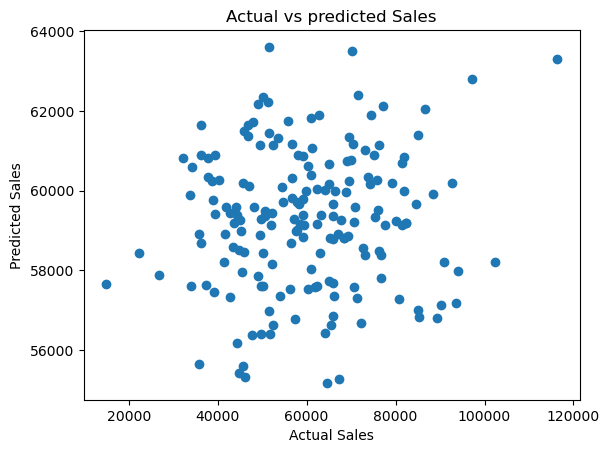

In [40]:
plt.scatter(y_test,predictions)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs predicted Sales")
plt.show()


# Feature Engineering

In [44]:
# Sales per customer

sales['Sales_Per_Customer'] = (
    sales['Store_Sales']/
    sales['Daily_Customer_Count']
)

# HOW MUCH REVENUE DOES EACH CUSTOMER GENRATE 

print(sales['Sales_Per_Customer'].head(5))


0    125.452830
1    189.619048
2     75.013889
3     86.661290
4    103.600000
Name: Sales_Per_Customer, dtype: float64


In [46]:
# 2.Items Per Area

sales['Items_Per_Area'] = (
    sales['Items_Available']/
    sales['Store_Area']
)

# HOW DENSLY PACKED IS  THE STORE 

In [48]:
# 3. Sales_Per_Area

sales['Sales_Per_Area'] = (
    sales['Store_Sales']/
    sales['Store_Area']
)

# HOW EFFECIENTLY IS STORE SPACE BEING  USED 

In [50]:
# Cuatomer_Per_Area

# HOW BUSY IS THE STORE 

sales['Customer_Per_Area'] = (
    sales['Daily_Customer_Count']/
    sales['Store_Area']
)

# HOW BUSY IS THE STORE 

In [52]:
sales.corr(numeric_only=True)['Store_Sales'].sort_values(ascending = False)

Store_Sales             1.000000
Sales_Per_Area          0.826939
Sales_Per_Customer      0.139546
Items_Available         0.098849
Store_Area              0.097474
Store ID                0.071486
Items_Per_Area          0.023145
Daily_Customer_Count    0.008629
Customer_Per_Area      -0.030558
Name: Store_Sales, dtype: float64

# Skills Used:
    • Pandas
    • Data Cleaning
    • Data Visualization
    • Correlation Analysis
    • Linear Regression
    • Business Insights
    
    Lesson Learned:
    Good models require good data.